# Reading Data
- Connect to drive
- Read the csv
- Little manipulation on data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="notebook")

csv_path = "/content/drive/MyDrive/myScreenTime.csv"  # dosya

df = pd.read_csv(
    csv_path,
    sep=";",
    na_values=["null"] # "null" strings become NaN
)

display(df.head(10))
df.info()


,date,total_minutes,social_minutes,productivity&finance_minutes,entertainment_minutes,creativity_minutes,travel_minutes,shopping&food_minutes,reading_minutes,games_minutes,other_minutes,notifications,pickups,exam_day,activiy,weekend
0,13.10.2025,469,247,105,26,10,6,1,0,0,4,NaN,NaN,0,0,0
1,14.10.2025,261,196,2,2,8,4,24,0,0,1,NaN,NaN,0,0,0
2,15.10.2025,285,163,5,5,5,24,15,0,0,4,NaN,NaN,0,1,0
3,16.10.2025,386,232,38,4,3,13,0,1,4,6,NaN,NaN,0,1,0
4,17.10.2025,432,215,92,0,12,16,0,1,0,3,NaN,NaN,0,1,0
5,18.10.2025,498,287,13,0,95,7,2,1,0,12,NaN,NaN,0,1,1
6,19.10.2025,917,291,19,2,41,17,5,0,58,2,NaN,NaN,0,1,1
7,20.10.2025,698,329,208,3,16,12,4,1,0,15,772.0,249.0,0,0,0
8,21.10.2025,680,269,222,16,6,11,5,0,0,0,778.0,199.0,0,1,0
9,22.10.2025,567,192,265,1,3,8,0,10,37,16,539.0,253.0,0,1,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   date                          46 non-null     object 
 1   total_minutes                 46 non-null     int64  
 2   social_minutes                46 non-null     int64  
 3   productivity&finance_minutes  46 non-null     int64  
 4   entertainment_minutes         46 non-null     int64  
 5   creativity_minutes            46 non-null     int64  
 6   travel_minutes                46 non-null     int64  
 7   shopping&food_minutes         46 non-null     int64  
 8   reading_minutes               46 non-null     int64  
 9   games_minutes                 46 non-null     int64  
 10  other_minutes                 46 non-null     int64  
 11  notifications                 39 non-null     float64
 12  pickups                       39 non-null     float64
 13  exam_da

#Data Preperation and EDA
Split the fields according to their behavior and change some names which I think will be better.


In [3]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

# Rename columns with special characters / typos
rename_map = {
    "productivity&finance_minutes": "productivity_finance_minutes",
    "shopping&food_minutes": "shopping_food_minutes",
    "activiy": "activity"
}
df = df.rename(columns=rename_map)
# binary columns
binary_columns = ["activity", "weekend", "exam_day"]

# Numeric columns
numeric_cols = [
    "total_minutes",
    "social_minutes",
    "productivity_finance_minutes",
    "entertainment_minutes",
    "creativity_minutes",
    "travel_minutes",
    "shopping_food_minutes",
    "reading_minutes",
    "games_minutes",
    "other_minutes",
    "notifications",
    "pickups",
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("Missing values per column:")
print(df.isna().sum())


Missing values per column:
date                            0
total_minutes                   0
social_minutes                  0
productivity_finance_minutes    0
entertainment_minutes           0
creativity_minutes              0
travel_minutes                  0
shopping_food_minutes           0
reading_minutes                 0
games_minutes                   0
other_minutes                   0
notifications                   7
pickups                         7
exam_day                        0
activity                        0
weekend                         0
dtype: int64


# Total Screen Time Over Time (Date)

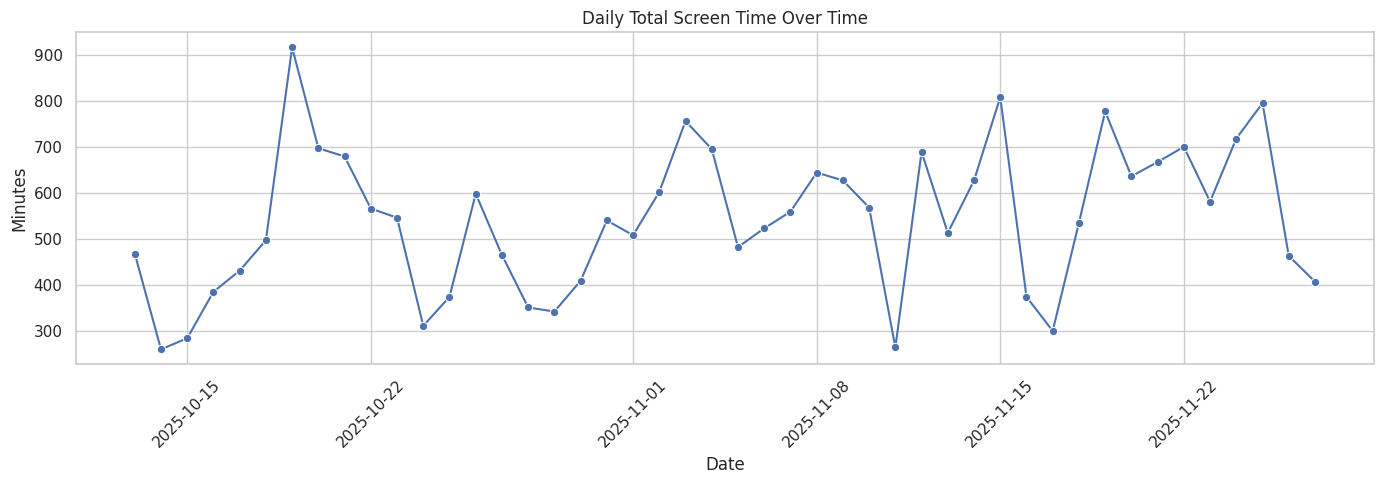

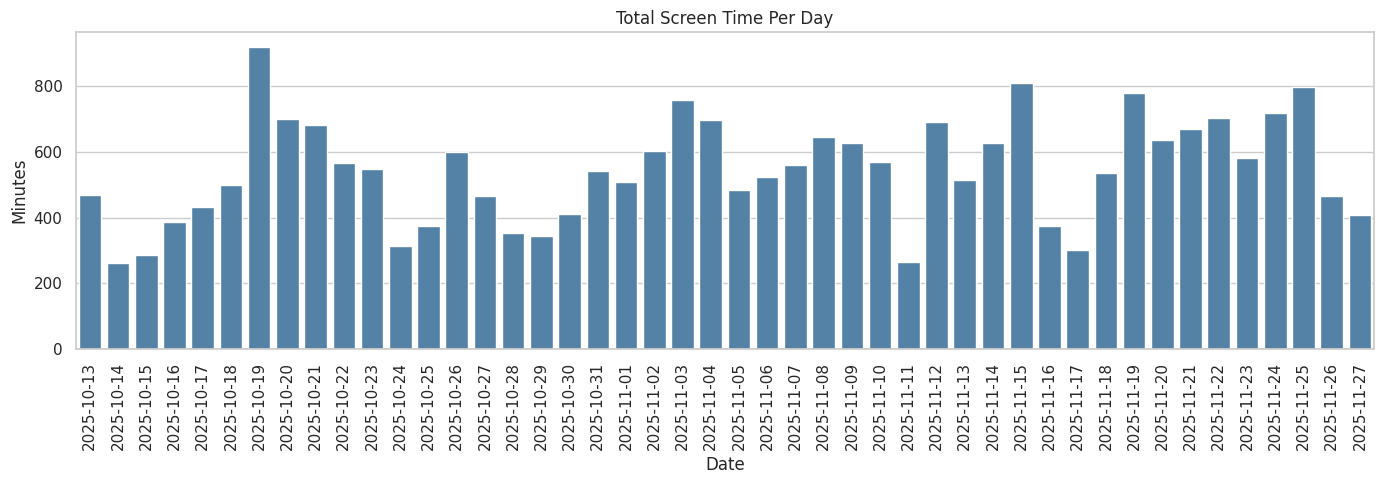

In [4]:
# ----------------------- Plot: Line chart of screen time over time
plt.figure(figsize=(14, 5))
sns.lineplot(data=df, x="date", y="total_minutes", marker="o")
plt.title("Daily Total Screen Time Over Time")
plt.xlabel("Date")
plt.ylabel("Minutes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("")
# ----------------------- Histogram bar chart: Total minutes per day
plt.figure(figsize=(14, 5))
sns.barplot(data=df, x="date", y="total_minutes", color="steelblue")

# rotate date labels
plt.xticks(rotation=90)
plt.title("Total Screen Time Per Day")
plt.xlabel("Date")
plt.ylabel("Minutes")
plt.tight_layout()
plt.show()


# Most popular categories over Date
In this section you can see that my productivity_minutes fluctuates more than the social minutes. It is because studies on my phone contributes to my productivity minutes and some periods I do not study that much or some periods I study much more, on the other hand I generally use social media which contributes to social_minutes here and its always in a range.

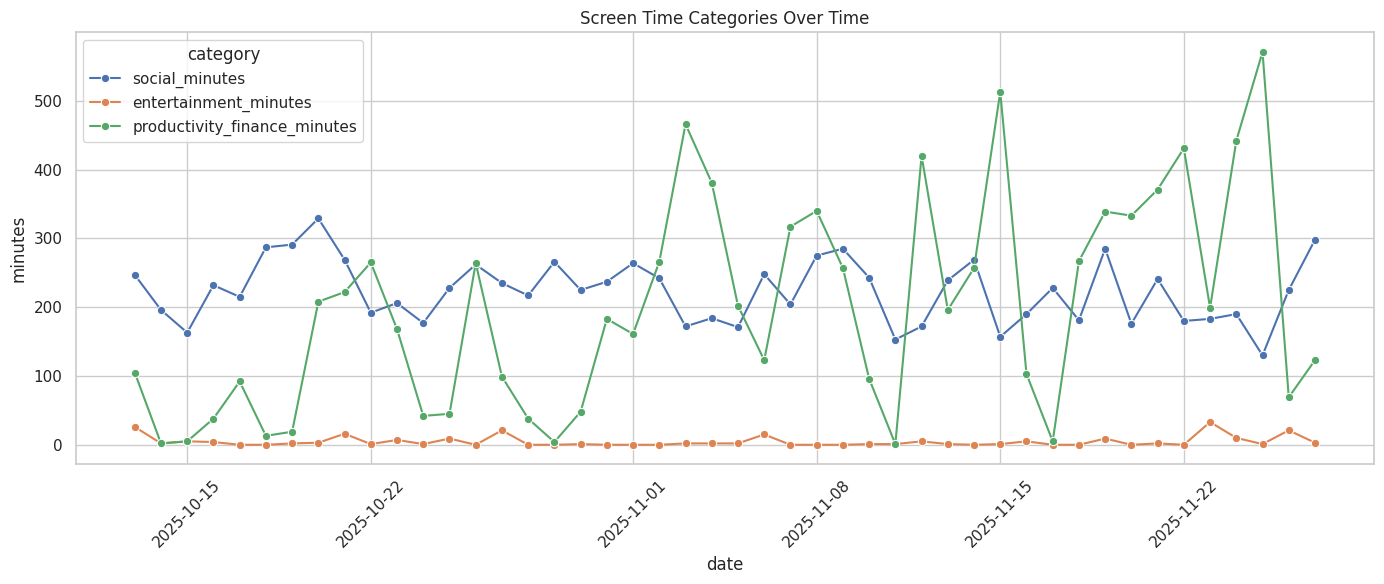

In [5]:
# Comparison of the most used categories
plt.figure(figsize=(14,6))

category_cols = [                     # fields that I want to show
    "social_minutes",
    "entertainment_minutes",
    "productivity_finance_minutes"
]

df_melt = df.melt(
    id_vars="date",
    value_vars=category_cols,
    var_name="category",
    value_name="minutes"
)

sns.lineplot(data=df_melt, x="date", y="minutes", hue="category", marker="o")
plt.title("Screen Time Categories Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [6]:
# ================================
# 1. Summary Statistics
# ================================
print("=== Summary Statistics (Behavioral Columns) ===")
display(df[numeric_cols].describe().T)  # I did not add the binary fields that is why I seperated them above
print("")

=== Summary Statistics (Behavioral Columns) ===


,count,mean,std,min,25%,50%,75%,max
total_minutes,46.0,543.108696,159.536444,261.0,415.50,544.0,662.25,917.0
social_minutes,46.0,223.021739,45.549723,130.0,183.25,226.5,258.50,329.0
productivity_finance_minutes,46.0,198.021739,155.748728,1.0,53.25,189.5,304.50,571.0
entertainment_minutes,46.0,4.608696,7.605490,0.0,0.00,1.0,5.00,33.0
creativity_minutes,46.0,11.000000,17.678612,0.0,3.00,5.0,11.50,95.0
travel_minutes,46.0,23.978261,25.622463,0.0,7.25,16.5,29.75,127.0
shopping_food_minutes,46.0,7.521739,10.487536,0.0,1.00,3.5,10.00,55.0
reading_minutes,46.0,1.826087,4.132819,0.0,0.00,0.5,1.00,25.0
games_minutes,46.0,2.173913,10.036166,0.0,0.00,0.0,0.00,58.0
other_minutes,46.0,11.239130,14.280032,0.0,2.00,5.5,13.00,60.0


#Notifications vs Screen Time
There is a weak positive trend: more notifications generally correspond to higher daily screen time, suggesting that notifications may prompt additional device usage.

#Pickups vs Screen Time
A similar weak positive trend appears for pickups. Days with more device pickups tend to have higher total screen time, indicating that frequent phone checking is linked to increased usage.

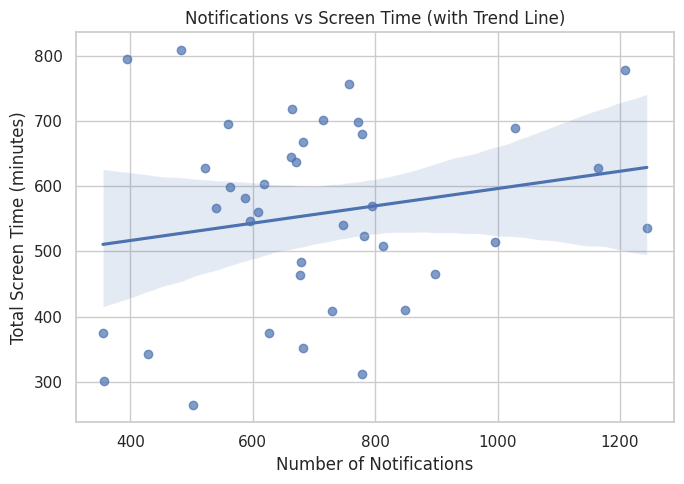

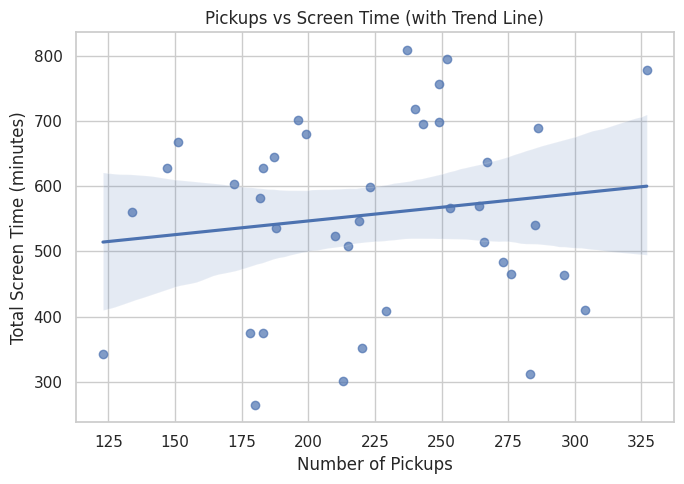

In [7]:
# ================================
# Notifications vs Total Screen Time
# ================================
plt.figure(figsize=(7,5))
sns.regplot(data=df, x="notifications", y="total_minutes", scatter_kws={'alpha':0.7})
plt.title("Notifications vs Screen Time (with Trend Line)")
plt.xlabel("Number of Notifications")
plt.ylabel("Total Screen Time (minutes)")
plt.tight_layout()
plt.show()
print("")

# ================================
# Pickups vs Total Screen Time
# ================================
plt.figure(figsize=(7,5))
sns.regplot(data=df, x="pickups", y="total_minutes", scatter_kws={'alpha':0.7})
plt.title("Pickups vs Screen Time (with Trend Line)")
plt.xlabel("Number of Pickups")
plt.ylabel("Total Screen Time (minutes)")
plt.tight_layout()
plt.show()
print("")


#Correlation Heatmap/Matrix

The heatmap shows several meaningful relationships among screen-time variables:

- Total screen time is strongly positively correlated with
productivity_finance_minutes, other_minutes, and games_minutes, suggesting these categories contribute most to overall usage.

- Productivity_finance_minutes has a notable negative correlation with
social_minutes, shopping_food_minutes, and activity, indicating that higher productivity often coincides with reduced entertainment or social behavior. The reason for that may be my note application (Collanote) which I use to study increases my productivity time.

- exam_day shows a mild negative correlation with total screen time, consistent with the expectation that screen usage decreases on exam days.

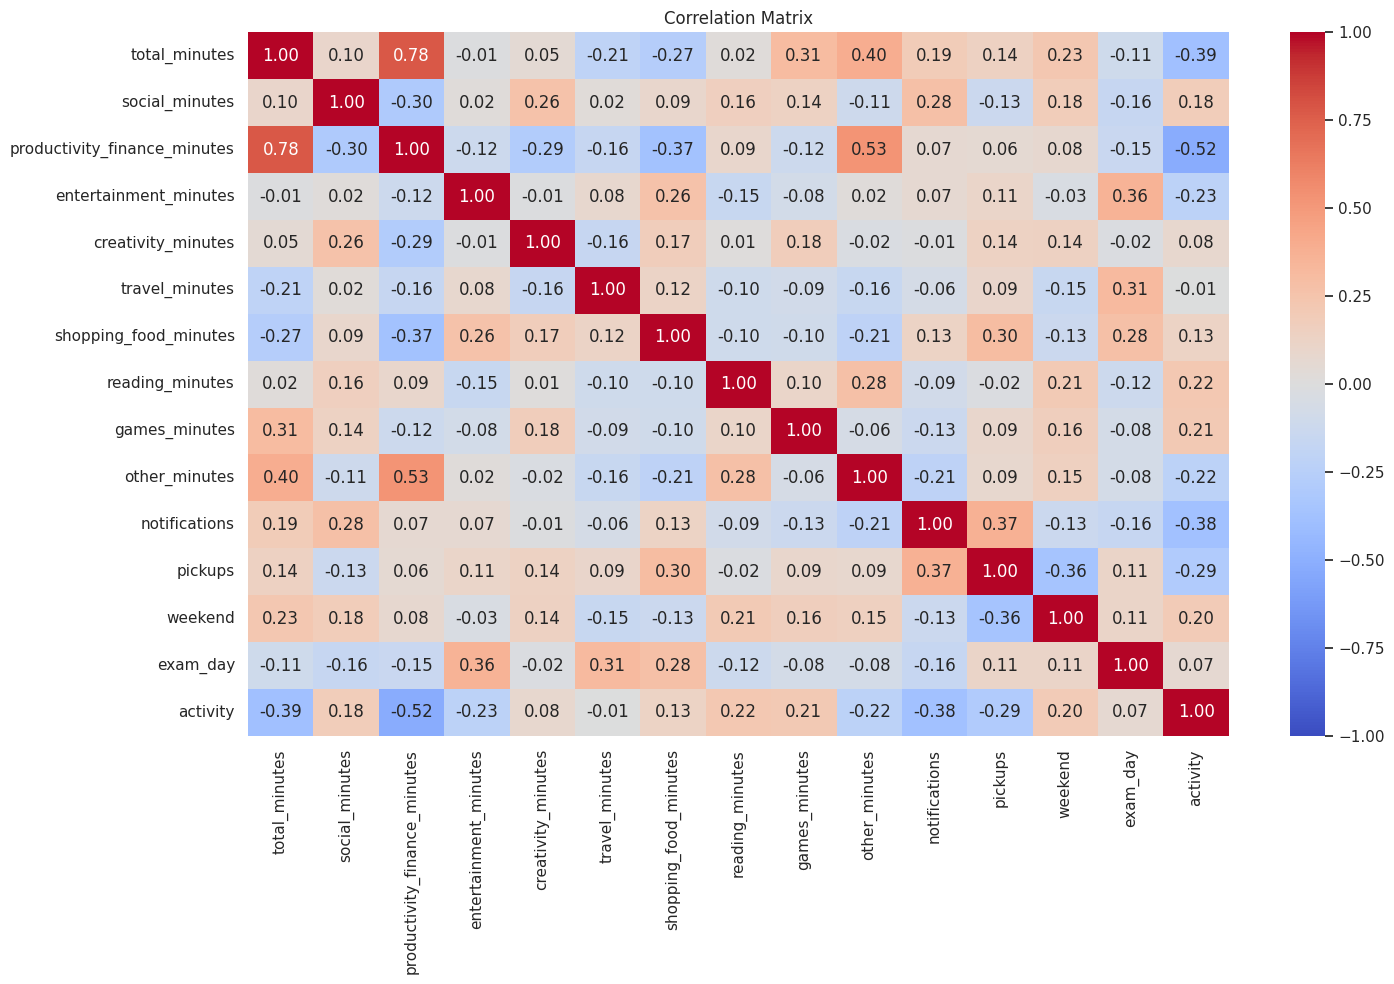

In [8]:
# ================================
# 6. Correlation Heatmap
# ================================
corr_cols = [
    "total_minutes",
    "social_minutes",
    "productivity_finance_minutes",
    "entertainment_minutes",
    "creativity_minutes",
    "travel_minutes",
    "shopping_food_minutes",
    "reading_minutes",
    "games_minutes",
    "other_minutes",
    "notifications",
    "pickups",
    "weekend",
    "exam_day",
    "activity"
]

plt.figure(figsize=(15,10))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


#Average Screen Time Categories: Normal vs Special Days

This chart compares average screen time across key categories on Normal Days and Special Days (exam or activity days). Overall, Special Days show noticeably lower usage—especially in productivity and social categories—indicating reduced phone engagement during academically or socially demanding days.

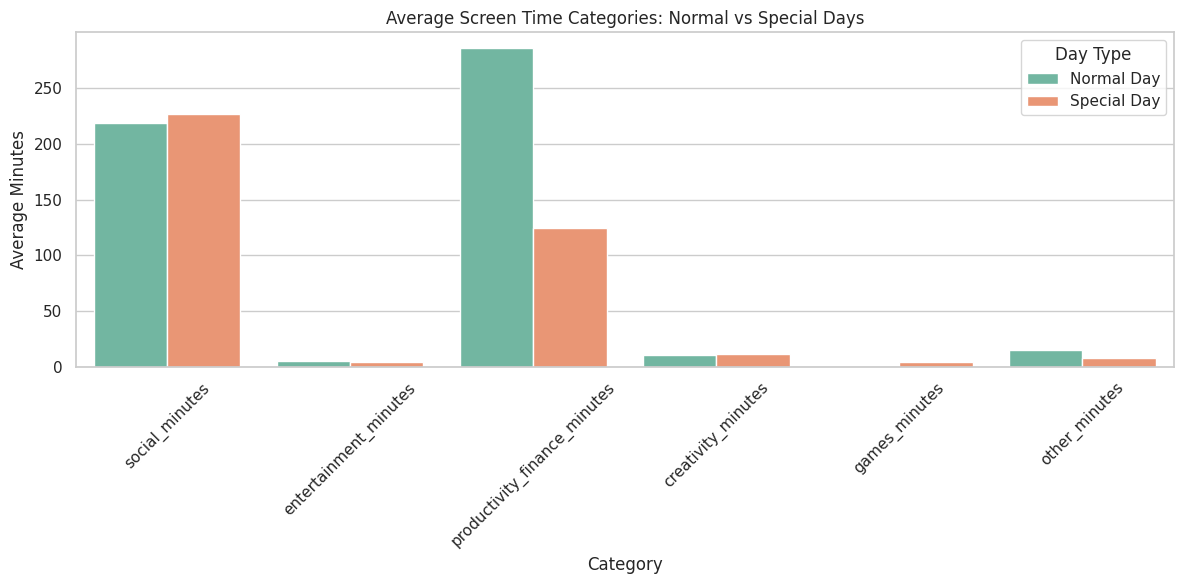

In [9]:
# Create a "day_type" column that labels each day as either:
# - "Normal Day"  → no exam and no activity
# - "Special Day" → exam day or activity day
df["day_type"] = df.apply(
    lambda row: "Normal Day" if (row["activity"] == 0 and row["exam_day"] == 0) else "Special Day",
    axis=1
)

# Adding the categories I want
category_cols = [
    "social_minutes",
    "entertainment_minutes",
    "productivity_finance_minutes",
    "creativity_minutes",
    "games_minutes",
    "other_minutes"
]

# Compare average total screen time for reference
df.groupby("day_type")["total_minutes"].mean()

# Plot average category minutes for each day type
plt.figure(figsize=(12,6))

category_means = df.groupby("day_type")[category_cols].mean().T

sns.barplot(
    data=category_means.reset_index().melt(id_vars="index", var_name="Day Type", value_name="Minutes"),
    x="index",
    y="Minutes",
    hue="Day Type",
    palette="Set2"
)

plt.title("Average Screen Time Categories: Normal vs Special Days")
plt.xlabel("Category")
plt.ylabel("Average Minutes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# **Hypothesis Testing**
In this section, I test whether my productivity-related screen time changes depending on the exam schedule. I divided each day into one of three groups:

Before Exam – the day right before an exam

Exam Day – the actual exam day

After Exam – the day right after an exam

My goal is to see if these three groups show different levels of productivity screen time.

In [10]:
# Copy df and ensure sorted order
df = df.sort_values("date").reset_index(drop=True)

# Initialize the new column
df["exam_group"] = "After Exam"   # default placeholder

# Iterate through exam days and assign groups
for i in range(len(df)):
    if df.loc[i, "exam_day"] == 1:
        # Mark the exam day
        df.loc[i, "exam_group"] = "Exam Day"

        # Mark the day before exam (if exists)
        if i - 1 >= 0:
            df.loc[i - 1, "exam_group"] = "Before Exam"

        # Mark the day after exam (if exists)
        if i + 1 < len(df):
            df.loc[i + 1, "exam_group"] = "After Exam"

df[["date", "exam_day", "exam_group", "productivity_finance_minutes"]]

#extracting p values
before = df[df["exam_group"] == "Before Exam"]["productivity_finance_minutes"].dropna()
exam = df[df["exam_group"] == "Exam Day"]["productivity_finance_minutes"].dropna()
after = df[df["exam_group"] == "After Exam"]["productivity_finance_minutes"].dropna()

#samples
len(before), len(exam), len(after)


(5, 5, 36)

Run a one-way ANOVA, which checks whether the mean productivity minutes differ across the three groups.

In [11]:
from scipy.stats import f_oneway   # to run one way ANOVA

anova_result = f_oneway(before, exam, after)
anova_result


F_onewayResult(statistic=np.float64(8.556994578212073), pvalue=np.float64(0.0007440420814042841))

### This output shows:
F-statistic = 8.56

p-value = 0.000744

In [12]:
if anova_result.pvalue < 0.05:
    print("Reject H0: Productivity screen time differs significantly between groups.")
else:
    print("Fail to Reject H0: No significant difference found between the groups.")


Reject H0: Productivity screen time differs significantly between groups.


There is a statistically significant difference in productivity screen time between at least one pair of groups.

Since the ANOVA showed a significant difference, I use Tukey’s HSD to find which groups are actually different from each other.

In [14]:
############
# Tukey Post-Hoc Test
# After finding a significant difference across groups with ANOVA,
# use Tukey's HSD to determine which specific pairs of exam groups differ significantly.
# This controls for multiple comparisons and identifies the exact group-to-group differences in productivity screen time.
############

import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=df["productivity_finance_minutes"],  # numeric variable
    groups=df["exam_group"],                   # categorical group labels
    alpha=0.05                                  # significance level
)

print(tukey)


       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1      group2   meandiff p-adj    lower    upper   reject
-----------------------------------------------------------------
 After Exam Before Exam 255.9611 0.0007   99.8452  412.077   True
 After Exam    Exam Day -40.8389 0.8017 -196.9548  115.277  False
Before Exam    Exam Day   -296.8 0.0032 -503.6814 -89.9186   True
-----------------------------------------------------------------


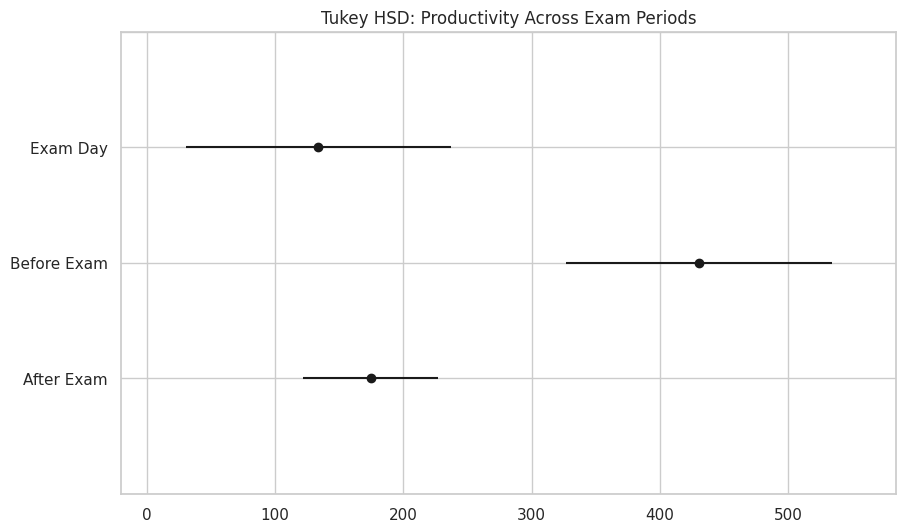

In [15]:
tukey.plot_simultaneous(figsize=(10,6))
plt.title("Tukey HSD: Productivity Across Exam Periods")
plt.show()


Overall Interpretation

These results support my hypothesis:

- I spend significantly more time on productivity apps before an exam, likely because I study more on those days.
- Productivity drops on the exam day and stays low the day after, probably because the studying pressure decreases.

This shows a clear behavioral pattern in my screen-time usage around exam periods.

You can see my code preparation in this link: https://chatgpt.com/share/6929f993-b800-8010-b3dd-b7097caf5b4f

# Applying ML Models
First, upload the data that will be predicted/evaluated (df_eval)

In [49]:
# Load the evaluation dataset (df_eval)
# This dataset represents real, unseen days that will be
# used only for prediction and external evaluation.

csv_path2 = "/content/drive/MyDrive/myScreenTime_2.csv"

df_eval = pd.read_csv(
    csv_path2,
    sep=";",
    na_values=["null"]  # Convert string "null" values into NaN
)

# Quick inspection to ensure correct loading
display(df_eval.head(10))
df_eval.info()

# Data preparation for ML compatibility
# Convert date column to datetime format
df_eval["date"] = pd.to_datetime(df_eval["date"], dayfirst=True)


rename_map = {
    "productivity&finance_minutes": "productivity_finance_minutes",
    "shopping&food_minutes": "shopping_food_minutes",
    "activiy": "activity"  # typo correction
}
df_eval = df_eval.rename(columns=rename_map)

# -------------------------------------------------------
# Define column groups
# -------------------------------------------------------

# Binary context variables (0/1)
binary_columns = ["activity", "weekend", "exam_day"]

# Numeric variables (screen time + interaction features)
numeric_cols = [
    "total_minutes",
    "social_minutes",
    "productivity_finance_minutes",
    "entertainment_minutes",
    "creativity_minutes",
    "travel_minutes",
    "shopping_food_minutes",
    "reading_minutes",
    "games_minutes",
    "other_minutes",
    "notifications",
    "pickups",
]

# Ensure numeric columns are properly parsed
for col in numeric_cols:
    if col in df_eval.columns:
        df_eval[col] = pd.to_numeric(df_eval[col], errors="coerce")


print("Missing values per column:")
print(df_eval.isna().sum())


,date,total_minutes,social_minutes,productivity&finance_minutes,entertainment_minutes,creativity_minutes,travel_minutes,shopping&food_minutes,reading_minutes,games_minutes,other_minutes,notifications,pickups,exam_day,activiy,weekend
0,8.12.2025,303,263,0,15,20,3,0,0,0,2,701,230,0,0,0
1,9.12.2025,321,239,2,31,0,36,1,1,0,1,446,147,0,0,0
2,10.12.2025,349,260,4,1,0,18,6,0,0,6,547,158,1,1,0
3,11.12.2025,255,192,8,5,0,3,0,0,0,1,425,225,0,0,0
4,12.12.2025,413,370,0,0,0,19,4,0,0,3,450,162,0,0,0
5,13.12.2025,233,146,1,0,9,15,0,1,0,2,442,226,0,1,1
6,14.12.2025,249,150,7,5,5,17,0,3,0,2,350,222,0,1,1
7,15.12.2025,433,350,8,12,3,7,4,3,0,8,1229,237,0,0,0
8,16.12.2025,401,265,5,1,2,76,22,2,0,8,833,165,0,0,0
9,17.12.2025,389,263,11,2,3,4,7,1,0,10,674,230,0,1,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   date                          21 non-null     object
 1   total_minutes                 21 non-null     int64 
 2   social_minutes                21 non-null     int64 
 3   productivity&finance_minutes  21 non-null     int64 
 4   entertainment_minutes         21 non-null     int64 
 5   creativity_minutes            21 non-null     int64 
 6   travel_minutes                21 non-null     int64 
 7   shopping&food_minutes         21 non-null     int64 
 8   reading_minutes               21 non-null     int64 
 9   games_minutes                 21 non-null     int64 
 10  other_minutes                 21 non-null     int64 
 11  notifications                 21 non-null     int64 
 12  pickups                       21 non-null     int64 
 13  exam_day              

In [48]:
# Prepare the training dataset (df_train) for ML modeling

df_train = df.copy()

# Handle missing values bc Regression does not accept


# 1) Convert common string representations of missing values into NaN
df_train = df_train.replace(
    ["null", "NULL", "None", "none", ""],
    np.nan
)

# Handle binary context variables (0/1)
#    If missing, assume 0:
for c in ["exam_day", "activity", "weekend"]:
    df_train[c] = (
        pd.to_numeric(df_train[c], errors="coerce")
        .fillna(0)
        .astype(int)
    )

# Handle numeric interaction variables
for c in ["notifications", "pickups"]:
    df_train[c] = pd.to_numeric(df_train[c], errors="coerce")
    df_train[c] = df_train[c].fillna(df_train[c].median())

# Target variable must not contain missing values
# Rows without total_minutes cannot be used for supervised learning
df_train["total_minutes"] = pd.to_numeric(
    df_train["total_minutes"], errors="coerce"
)
df_train = df_train.dropna(subset=["total_minutes"]).reset_index(drop=True)

# Check: confirm no missing values remain

print("Remaining NaNs in df_train (should be all zeros):")
print(
    df_train[
        ["total_minutes", "notifications", "pickups",
         "exam_day", "activity", "weekend"]
    ].isna().sum()
)

display(df_train.head(10))
df_train.info()


Remaining NaNs in df_train (should be all zeros):
total_minutes    0
notifications    0
pickups          0
exam_day         0
activity         0
weekend          0
dtype: int64


,date,total_minutes,social_minutes,productivity_finance_minutes,entertainment_minutes,creativity_minutes,travel_minutes,shopping_food_minutes,reading_minutes,games_minutes,other_minutes,notifications,pickups,exam_day,activity,weekend,day_type,exam_group
0,2025-10-13,469,247,105,26,10,6,1,0,0,4,679.0,223.0,0,0,0,Normal Day,After Exam
1,2025-10-14,261,196,2,2,8,4,24,0,0,1,679.0,223.0,0,0,0,Normal Day,After Exam
2,2025-10-15,285,163,5,5,5,24,15,0,0,4,679.0,223.0,0,1,0,Special Day,After Exam
3,2025-10-16,386,232,38,4,3,13,0,1,4,6,679.0,223.0,0,1,0,Special Day,After Exam
4,2025-10-17,432,215,92,0,12,16,0,1,0,3,679.0,223.0,0,1,0,Special Day,After Exam
5,2025-10-18,498,287,13,0,95,7,2,1,0,12,679.0,223.0,0,1,1,Special Day,After Exam
6,2025-10-19,917,291,19,2,41,17,5,0,58,2,679.0,223.0,0,1,1,Special Day,After Exam
7,2025-10-20,698,329,208,3,16,12,4,1,0,15,772.0,249.0,0,0,0,Normal Day,After Exam
8,2025-10-21,680,269,222,16,6,11,5,0,0,0,778.0,199.0,0,1,0,Special Day,After Exam
9,2025-10-22,567,192,265,1,3,8,0,10,37,16,539.0,253.0,0,1,0,Special Day,After Exam


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   date                          46 non-null     datetime64[ns]
 1   total_minutes                 46 non-null     int64         
 2   social_minutes                46 non-null     int64         
 3   productivity_finance_minutes  46 non-null     int64         
 4   entertainment_minutes         46 non-null     int64         
 5   creativity_minutes            46 non-null     int64         
 6   travel_minutes                46 non-null     int64         
 7   shopping_food_minutes         46 non-null     int64         
 8   reading_minutes               46 non-null     int64         
 9   games_minutes                 46 non-null     int64         
 10  other_minutes                 46 non-null     int64         
 11  notifications                 46 n

#Time-Ordered Train/Holdout Split + Feature Matrices

In [50]:
# Create a time-ordered train/holdout split and build feature matrices for three model scenarios.
# - NOT shuffle because screen time is time-dependent.
# - The last 20% of days are used as a holdout test set.
# -------------------------------------------------------

# Feature sets for the three model scenarios
FEATURES_A = ["exam_day", "activity", "weekend"]          # Context-only
FEATURES_B = ["notifications", "pickups"]                # Interaction-only
FEATURES_C = FEATURES_A + FEATURES_B                     # Combined

# Target variable
TARGET = "total_minutes"

# Time-ordered split (no shuffle)

split_ratio = 0.8
split_idx = int(len(df_train) * split_ratio)

# Train = first 80% of the dataset, Test = last 20%
train_df = df_train.iloc[:split_idx].copy()
test_df  = df_train.iloc[split_idx:].copy()

print(f"Train split size: {len(train_df)}")
print(f"Holdout test size: {len(test_df)}")

# Create target vectors
y_train = train_df[TARGET]
y_test  = test_df[TARGET]

# Create feature matrices for each model (train/test/eval)

# Model A: Context-only features (exam day/ activity day/ weekend)
X_train_A = train_df[FEATURES_A]
X_test_A  = test_df[FEATURES_A]
X_eval_A  = df_eval[FEATURES_A]

# Model B: Interaction-only features (notifications / pickups)
X_train_B = train_df[FEATURES_B]
X_test_B  = test_df[FEATURES_B]
X_eval_B  = df_eval[FEATURES_B]

# Model C: Combined features
X_train_C = train_df[FEATURES_C]
X_test_C  = test_df[FEATURES_C]
X_eval_C  = df_eval[FEATURES_C]

print("Feature matrices created:")
print("Model A (Context):", X_train_A.shape, X_test_A.shape)
print("Model B (Interaction):", X_train_B.shape, X_test_B.shape)
print("Model C (Combined):", X_train_C.shape, X_test_C.shape)


Train split size: 36
Holdout test size: 10
Feature matrices created:
Model A (Context): (36, 3) (10, 3)
Model B (Interaction): (36, 2) (10, 2)
Model C (Combined): (36, 5) (10, 5)


# Train Linear Regression models + evaluate on train holdout

In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# --- Step 3: Train & evaluate on holdout set ---

def evaluate_regression(model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    mae = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2 = r2_score(y_te, y_pred)

    return mae, rmse, r2, model


results = []

# Model A: Context-only
mae_A, rmse_A, r2_A, model_A = evaluate_regression(
    LinearRegression(), X_train_A, y_train, X_test_A, y_test
)

results.append({
    "Model": "A (Context-only)",
    "Dataset": "Train Holdout",
    "MAE": mae_A,
    "RMSE": rmse_A,
    "R2": r2_A
})

# Model B: Interaction-only
mae_B, rmse_B, r2_B, model_B = evaluate_regression(
    LinearRegression(), X_train_B, y_train, X_test_B, y_test
)

results.append({
    "Model": "B (Interaction-only)",
    "Dataset": "Train Holdout",
    "MAE": mae_B,
    "RMSE": rmse_B,
    "R2": r2_B
})

# Model C: Combined
mae_C, rmse_C, r2_C, model_C = evaluate_regression(
    LinearRegression(), X_train_C, y_train, X_test_C, y_test
)

results.append({
    "Model": "C (Combined)",
    "Dataset": "Train Holdout",
    "MAE": mae_C,
    "RMSE": rmse_C,
    "R2": r2_C
})

# Results table (holdout)
holdout_results_df = pd.DataFrame(results)
holdout_results_df


,Model,Dataset,MAE,RMSE,R2
0,A (Context-only),Train Holdout,111.852886,133.976424,-0.181811
1,B (Interaction-only),Train Holdout,149.167908,167.256703,-0.841867
2,C (Combined),Train Holdout,112.060058,133.529920,-0.173946


The linear regression models have limited predictive capabilities over the time-ordered holdout set. The models with only context information and models including all pieces of information perform similarly. The model with only interaction information performs worse. All models display negative values of R². It can be said that linear regression models do not perform well in identifying patterns related to screen time. If that is the case, screen time patterns must be highly unpredictable. Although all identified factors might affect screen time including constraints of conditions related to certain factors of these factors, further analysis of these factors is done with the use of Decision Tree Regressor because of possible non-linearity.

#Decision Tree Regression (Model A: Context-only)

In [51]:
from sklearn.tree import DecisionTreeRegressor

# Decision Tree Regression (Model A - Context-only)
# - Train a DecisionTreeRegressor using context features only
# - Evaluate on the time-ordered holdout set
# - Predict on the external evaluation dataset (df_eval)

# 1) Train
dt_A = DecisionTreeRegressor(random_state=42)
dt_A.fit(X_train_A, y_train)

# 2) Evaluate on holdout
y_pred_test_A = dt_A.predict(X_test_A)

mae_A = mean_absolute_error(y_test, y_pred_test_A)
rmse_A = np.sqrt(mean_squared_error(y_test, y_pred_test_A))
r2_A = r2_score(y_test, y_pred_test_A)

print("Decision Tree - Model A (Context-only) | Holdout")
print(f"MAE : {mae_A:.4f}")
print(f"RMSE: {rmse_A:.4f}")
print(f"R^2 : {r2_A:.4f}")

# 3) Predict on df_eval
pred_eval_A = dt_A.predict(X_eval_A)

y_eval = df_eval["total_minutes"]
# Compute external evaluation metrics
mae_eval_A = mean_absolute_error(y_eval, pred_eval_A)
rmse_eval_A = np.sqrt(mean_squared_error(y_eval, pred_eval_A))
r2_eval_A = r2_score(y_eval, pred_eval_A)

print("Decision Tree - Model A (Context-only) | External df_eval")
print(f"MAE : {mae_eval_A:.4f}")
print(f"RMSE: {rmse_eval_A:.4f}")
print(f"R^2 : {r2_eval_A:.4f}")

# Preview first predictions for df_eval
pred_eval_A[:10]

Decision Tree - Model A (Context-only) | Holdout
MAE : 130.2682
RMSE: 149.5378
R^2 : -0.4723
Decision Tree - Model A (Context-only) | External df_eval
MAE : 209.1486
RMSE: 230.8161
R^2 : -10.7280


array([560.27272727, 560.27272727, 569.        , 560.27272727,
       560.27272727, 592.28571429, 592.28571429, 560.27272727,
       560.27272727, 424.69230769])

# Decision Tree Regression (Model B: Interaction-only)

In [53]:
# Decision Tree Regression - Model B (Interaction-only)
# Features:
# - notifications
# - pickups

# 1) Train
dt_B = DecisionTreeRegressor(random_state=42)
dt_B.fit(X_train_B, y_train)

# 2) Evaluate on holdout
y_pred_test_B = dt_B.predict(X_test_B)

mae_B = mean_absolute_error(y_test, y_pred_test_B)
rmse_B = np.sqrt(mean_squared_error(y_test, y_pred_test_B))
r2_B = r2_score(y_test, y_pred_test_B)

print("Decision Tree - Model B (Interaction-only) | Holdout")
print(f"MAE : {mae_B:.4f}")
print(f"RMSE: {rmse_B:.4f}")
print(f"R^2 : {r2_B:.4f}")

# 3) Predict on df_eval
pred_eval_B = dt_B.predict(X_eval_B)

# 4) External evaluation on df_eval
y_eval = df_eval["total_minutes"]

mae_eval_B = mean_absolute_error(y_eval, pred_eval_B)
rmse_eval_B = np.sqrt(mean_squared_error(y_eval, pred_eval_B))
r2_eval_B = r2_score(y_eval, pred_eval_B)

print("\nDecision Tree - Model B (Interaction-only) | External df_eval")
print(f"MAE : {mae_eval_B:.4f}")
print(f"RMSE: {rmse_eval_B:.4f}")
print(f"R^2 : {r2_eval_B:.4f}")

# pred_eval_B now contains predictions for df_eval
pred_eval_B[:10]

Decision Tree - Model B (Interaction-only) | Holdout
MAE : 215.2000
RMSE: 263.6319
R^2 : -3.5760

Decision Tree - Model B (Interaction-only) | External df_eval
MAE : 163.2381
RMSE: 204.8168
R^2 : -8.2347


array([352., 343., 628., 301., 375., 301., 301., 509., 628., 464.])

# Decision Tree Regression (Model C: Combined)

In [55]:
# Decision Tree Regression - Model C (Combined)
# Features:
# - Context variables: exam_day, activity, weekend
# - Interaction variables: notifications, pickups

# 1) Train
dt_C = DecisionTreeRegressor(random_state=42)
dt_C.fit(X_train_C, y_train)

# 2) Evaluate on holdout test set
y_pred_test_C = dt_C.predict(X_test_C)

mae_C = mean_absolute_error(y_test, y_pred_test_C)
rmse_C = np.sqrt(mean_squared_error(y_test, y_pred_test_C))
r2_C = r2_score(y_test, y_pred_test_C)

print("Decision Tree - Model C (Combined) | Holdout")
print(f"MAE : {mae_C:.4f}")
print(f"RMSE: {rmse_C:.4f}")
print(f"R^2 : {r2_C:.4f}")

# 3) Predict on external evaluation dataset (df_eval)
pred_eval_C = dt_C.predict(X_eval_C)

# 4) External evaluation on df_eval (total_minutes is known to exist)
y_eval = df_eval["total_minutes"]

mae_eval_C = mean_absolute_error(y_eval, pred_eval_C)
rmse_eval_C = np.sqrt(mean_squared_error(y_eval, pred_eval_C))
r2_eval_C = r2_score(y_eval, pred_eval_C)

print("\nDecision Tree - Model C (Combined) | External df_eval")
print(f"MAE : {mae_eval_C:.4f}")
print(f"RMSE: {rmse_eval_C:.4f}")
print(f"R^2 : {r2_eval_C:.4f}")

# Preview first predictions for df_eval
pred_eval_C[:10]

Decision Tree - Model C (Combined) | Holdout
MAE : 107.8000
RMSE: 171.7795
R^2 : -0.9428

Decision Tree - Model C (Combined) | External df_eval
MAE : 147.3492
RMSE: 182.4417
R^2 : -6.3272


array([365.        , 343.        , 628.        , 301.        ,
       343.        , 301.        , 301.        , 696.        ,
       524.        , 367.66666667])

# Decision Tree Comparison Table

In [57]:
# Decision Tree comparison table ---

results_dt = []

# -------- Model A (Context-only) --------
results_dt.append({
    "Model": "DT A (Context-only)",
    "Dataset": "Train Holdout",
    "MAE": mae_A,
    "RMSE": rmse_A,
    "R2": r2_A
})

if "total_minutes" in df_eval.columns:
    results_dt.append({
        "Model": "DT A (Context-only)",
        "Dataset": "External df_eval",
        "MAE": mae_eval_A,
        "RMSE": rmse_eval_A,
        "R2": r2_eval_A
    })

# -------- Model B (Interaction-only) --------
results_dt.append({
    "Model": "DT B (Interaction-only)",
    "Dataset": "Train Holdout",
    "MAE": mae_B,
    "RMSE": rmse_B,
    "R2": r2_B
})

if "total_minutes" in df_eval.columns:
    results_dt.append({
        "Model": "DT B (Interaction-only)",
        "Dataset": "External df_eval",
        "MAE": mae_eval_B,
        "RMSE": rmse_eval_B,
        "R2": r2_eval_B
    })

# -------- Model C (Combined) --------
results_dt.append({
    "Model": "DT C (Combined)",
    "Dataset": "Train Holdout",
    "MAE": mae_C,
    "RMSE": rmse_C,
    "R2": r2_C
})

if "total_minutes" in df_eval.columns:
    results_dt.append({
        "Model": "DT C (Combined)",
        "Dataset": "External df_eval",
        "MAE": mae_eval_C,
        "RMSE": rmse_eval_C,
        "R2": r2_eval_C
    })

# Final comparison DataFrame
dt_results_df = pd.DataFrame(results_dt)
dt_results_df.round(2)


,Model,Dataset,MAE,RMSE,R2
0,DT A (Context-only),Train Holdout,130.27,149.54,-0.47
1,DT A (Context-only),External df_eval,209.15,230.82,-10.73
2,DT B (Interaction-only),Train Holdout,215.20,263.63,-3.58
3,DT B (Interaction-only),External df_eval,163.24,204.82,-8.23
4,DT C (Combined),Train Holdout,107.80,171.78,-0.94
5,DT C (Combined),External df_eval,147.35,182.44,-6.33



# Conclusion
This study investigates daily screen time behavior based on real individual data combined with both contextual variables (exam days, days of activity, and weekend days) and notification/pickup cues. Exploratory data analysis and hypothesis testing showed interesting patterns for behavior related to exams, as well as high daily variability.

Linear Regression models were used as a baseline and showed limited predictive performance, with negative R² values indicating underfitting. Then, the Decision Tree Regression method was applied, considering the possibility of non-linear dependencies between variables. Unfortunately, the Decision Tree models had a poor generalization performance, as indicated by the overfitting, which was due to the small amount of data, as well as the noisy character of human behavior.

You can see my code preparation by this link: https://chatgpt.com/share/69582aee-44b0-8010-ae10-9735b025d4ca